In [10]:
%run "coli starting run.ipynb"

In [11]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_createII(50,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)
    #score_borad = pd.concat([score_borad,data_create(20,my_floor(true_score,-2),true_score,1)]).reset_index(drop=True)
    score_borad = pd.concat([score_borad,data_createII(50,my_floor(true_score,-2),true_score,2)]).reset_index(drop=True)



score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,20.0,100.0
1,100.0,101,0,0,0,0,0,0,20.0,100.0
2,100.0,101,0,0,0,0,0,0,20.0,100.0
3,100.0,101,0,0,0,0,0,0,20.0,100.0
4,100.0,101,0,0,0,0,0,0,20.0,100.0
...,...,...,...,...,...,...,...,...,...,...
4995,500.0,591,0,0,0,0,0,2,20.0,500.0
4996,500.0,591,0,0,0,0,0,2,20.0,500.0
4997,500.0,591,0,0,0,0,0,2,20.0,500.0
4998,500.0,591,0,0,0,0,0,2,20.0,500.0


In [12]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
2663,520.0,361,5,15,17,14,4,2,20.0,300.0,220.0
41,250.0,101,0,20,34,10,13,0,20.0,100.0,150.0
4944,840.0,591,0,20,6,16,4,0,20.0,500.0,340.0
1405,350.0,241,0,20,13,12,4,0,20.0,200.0,150.0
2332,480.0,331,0,20,25,15,6,0,20.0,300.0,180.0
...,...,...,...,...,...,...,...,...,...,...,...
237,160.0,121,0,20,19,11,4,0,20.0,100.0,60.0
1486,360.0,241,5,15,17,8,8,2,20.0,200.0,160.0
1770,400.0,271,5,15,13,11,5,2,20.0,200.0,200.0
2352,440.0,331,5,15,16,10,5,2,20.0,300.0,140.0


<AxesSubplot:xlabel='score', ylabel='true score'>

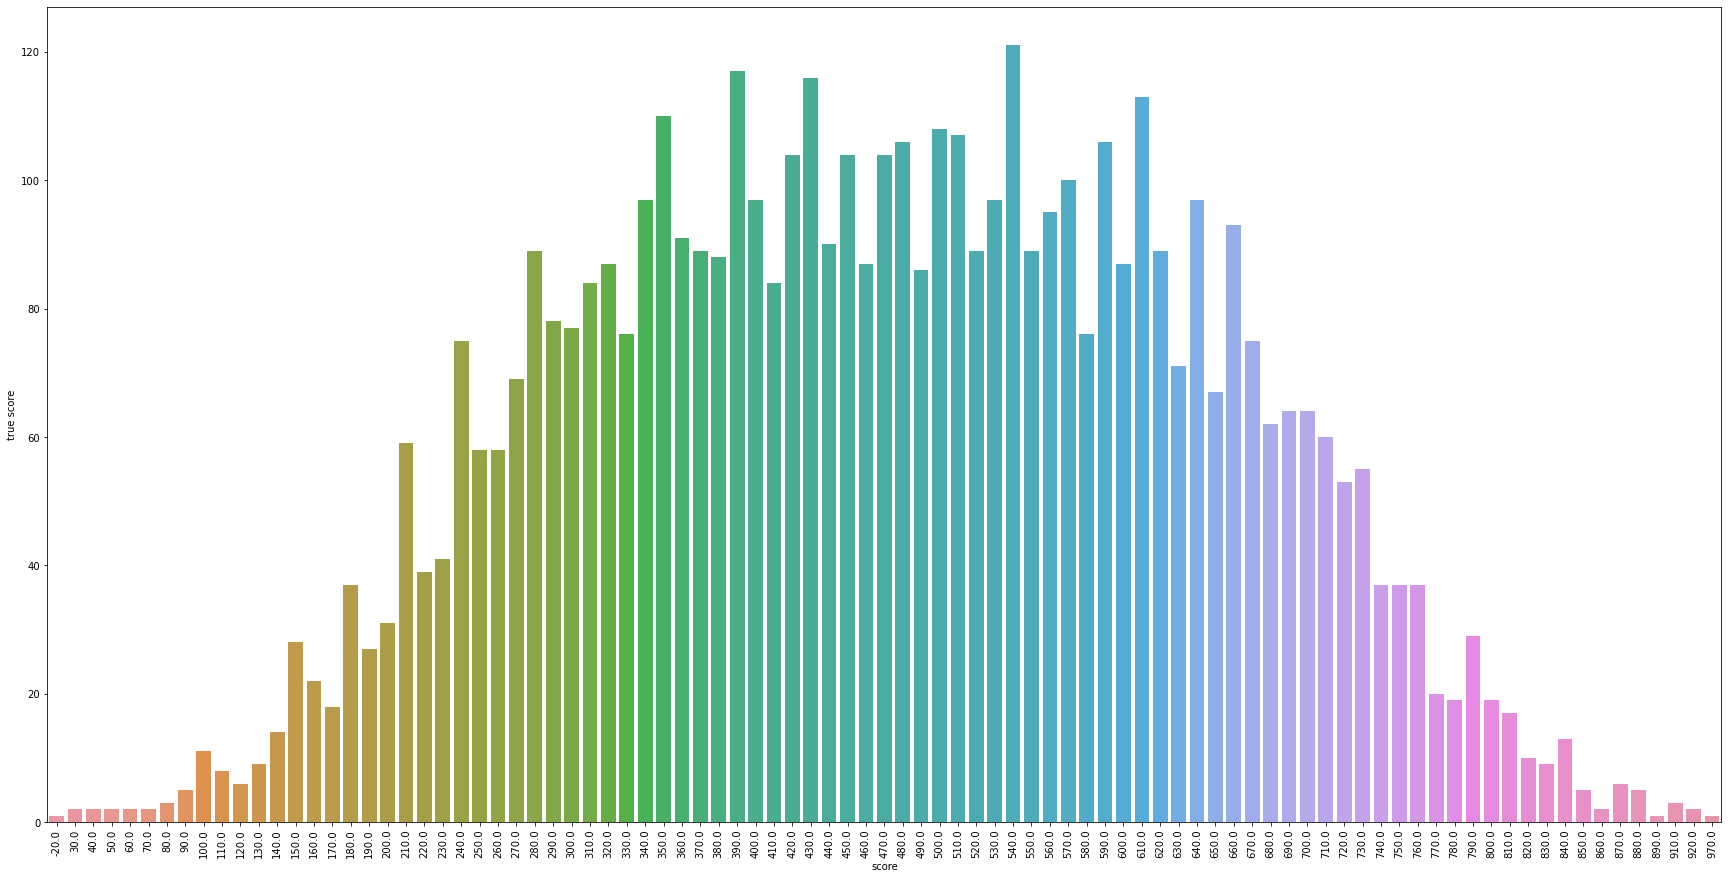

In [13]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

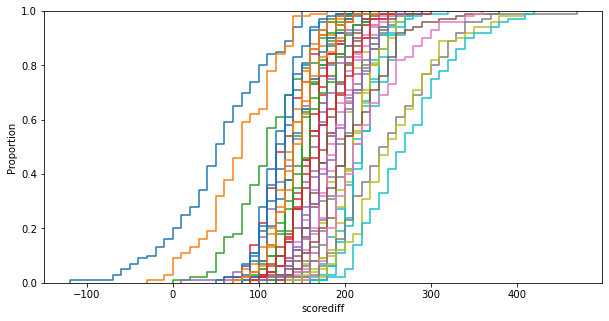

In [14]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [15]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

att count     att win        def count        def win        \
type               0   2       0      2         0      2       0     2   
true score                                                               
101               20  15   10.58   7.92     31.56  31.06    8.60  8.98   
111               20  15   11.02   8.28     26.88  24.10    7.18  7.40   
121               20  15   12.22   9.32     25.46  20.30    6.96  5.94   
131               20  15   11.98   9.30     24.50  19.48    7.28  6.48   
141               20  15   12.46   9.94     21.06  16.52    6.00  5.12   
151               20  15   13.04   9.82     20.42  16.64    5.90  6.12   
161               20  15   13.30  10.44     21.42  15.80    6.56  5.82   
171               20  15   13.72  10.70     18.38  12.96    5.66  4.94   
181               20  15   13.68  11.02     18.10  11.54    5.70  4.26   
191               20  15   14.02  11.76     17.24  10.00    5.48  3.80   
201               20  15   12.64   9.84     22.60  19.12    5.92  5.62   
211               20  15   12.78  10.20     19.98  20.06    5.12  6.00   
221               20  15   12.80  10.40     21.50  19.32    5.98  5.96   
231               20  15   12.70  10.46     21.30  16.36    6.40  5.32   
241               20  15   12.66  10.76     20.04  16.20    6.08  5.38   
251               20  15   13.42  10.70     21.02  16.30    6.14  5.80   
261               20  15   13.66  11.26     19.20  14.14    5.76  4.74   
271               20  15   13.54  11.22     17.36  13.64    5.38  5.02   
281               20  15   14.22  11.76     18.70  11.28    5.84  4.08   
291               20  15   14.56  11.88     17.94   8.04    5.50  2.80   
301               20  15   12.22  10.42     20.90  18.50    5.76  5.20   
311               20  15   12.92  10.02     21.82  18.66    5.78  5.76   
321               20  15   12.62  10.42     20.66  17.32    5.90  5.20   
331               20  15   13.30  10.72     22.26  17.12    6.32  5.14   
341               20  15   13.28  10.66     20.74  15.20    6.06  5.06   
351               20  15   13.48  10.72     20.32  16.16    5.98  5.68   
361               20  15   13.24  11.10     20.54  12.40    6.68  4.28   
371               20  15   13.96  11.28     16.78  11.88    5.00  4.42   
381               20  15   14.76  11.64     18.00  10.64    4.94  3.80   
391               20  15   14.70  11.94     16.58  11.76    4.92  4.22   
401               20  15   12.52  10.26     21.44  19.32    5.40  5.30   
411               20  15   12.78  10.64     21.76  20.06    5.84  5.88   
421               20  15   12.82  10.48     19.92  18.74    5.38  5.98   
431               20  15   12.46  10.60     20.14  17.82    6.36  5.54   
441               20  15   12.88  10.88     20.50  15.72    6.36  5.18   
451               20  15   13.58  10.78     19.72  14.76    5.70  5.02   
461               20  15   13.66  11.00     19.08  12.38    5.92  4.40   
471               20  15   13.96  11.40     18.76  13.46    5.82  4.76   
481               20  15   13.96  11.72     17.80   9.62    5.80  3.48   
491               20  15   14.64  12.28     16.34   8.94    4.90  3.30   
501               20  15   12.58  10.42     21.42  21.44    5.90  6.68   
511               20  15   12.64  10.60     20.18  16.94    5.58  5.04   
521               20  15   13.02  10.82     20.36  18.20    5.98  5.46   
531               20  15   12.66  10.18     20.32  16.50    6.90  5.70   
541               20  15   12.66  10.42     19.02  16.82    6.56  6.64   
551               20  15   13.32  10.96     19.34  12.70    7.28  4.82   
561               20  15   13.84  11.16     15.30  13.42    5.38  5.92   
571               20  15   14.56  11.92     14.64   9.48    6.22  3.88   
581               20  15   14.86  11.82      9.68   6.32    4.38  3.20   
591               20  15   15.92  12.92      3.56   2.32    1.92  1.16   

           int_score        play_time        score        scorediff         \
type      

In [16]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[400:499]

att count     att win        def count        def win        \
type               0   2       0      2         0      2       0     2   
true score                                                               
401               20  15   12.52  10.26     21.44  19.32    5.40  5.30   
411               20  15   12.78  10.64     21.76  20.06    5.84  5.88   
421               20  15   12.82  10.48     19.92  18.74    5.38  5.98   
431               20  15   12.46  10.60     20.14  17.82    6.36  5.54   
441               20  15   12.88  10.88     20.50  15.72    6.36  5.18   
451               20  15   13.58  10.78     19.72  14.76    5.70  5.02   
461               20  15   13.66  11.00     19.08  12.38    5.92  4.40   
471               20  15   13.96  11.40     18.76  13.46    5.82  4.76   
481               20  15   13.96  11.72     17.80   9.62    5.80  3.48   
491               20  15   14.64  12.28     16.34   8.94    4.90  3.30   

           int_score        play_time        score        scorediff         \
type               0      2         0     2      0      2         0      2   
true score                                                                   
401            400.0  400.0      20.0  20.0  523.2  523.6     123.2  123.6   
411            400.0  400.0      20.0  20.0  541.0  545.0     141.0  145.0   
421            400.0  400.0      20.0  20.0  546.8  556.4     146.8  156.4   
431            400.0  400.0      20.0  20.0  563.2  556.0     163.2  156.0   
441            400.0  400.0      20.0  20.0  572.2  574.6     172.2  174.6   
451            400.0  400.0      20.0  20.0  581.2  576.4     181.2  176.4   
461            400.0  400.0      20.0  20.0  596.6  588.2     196.6  188.2   
471            400.0  400.0      20.0  20.0  605.8  600.2     205.8  200.2   
481            400.0  400.0      20.0  20.0  614.8  609.8     214.8  209.8   
491            400.0  400.0      20.0  20.0  622.8  628.0     222.8  228.0   

           skiped time     
type                 0  2  
true score                 
401                  0  5  
411                  0  5  
421                  0  5  
431                  0  5  
441                  0  5  
451                  0  5  
461                  0  5  
471                  0  5  
481                  0  5  
491                  0  5

In [17]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399][['att count','def count','scorediff']]

att count     def count        scorediff       
type               0   2         0      2         0      2
true score                                                
301               20  15     20.90  18.50     130.4  133.6
311               20  15     21.82  18.66     142.8  136.8
321               20  15     20.66  17.32     149.0  145.4
331               20  15     22.26  17.12     166.0  154.6
341               20  15     20.74  15.20     172.8  169.6
351               20  15     20.32  16.16     180.6  180.4
361               20  15     20.54  12.40     192.2  187.4
371               20  15     16.78  11.88     201.0  202.2
381               20  15     18.00  10.64     211.0  206.8
391               20  15     16.58  11.76     222.8  217.2